In [39]:
import pandas as pd
df = pd.read_csv("Country-data.csv")
print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [40]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


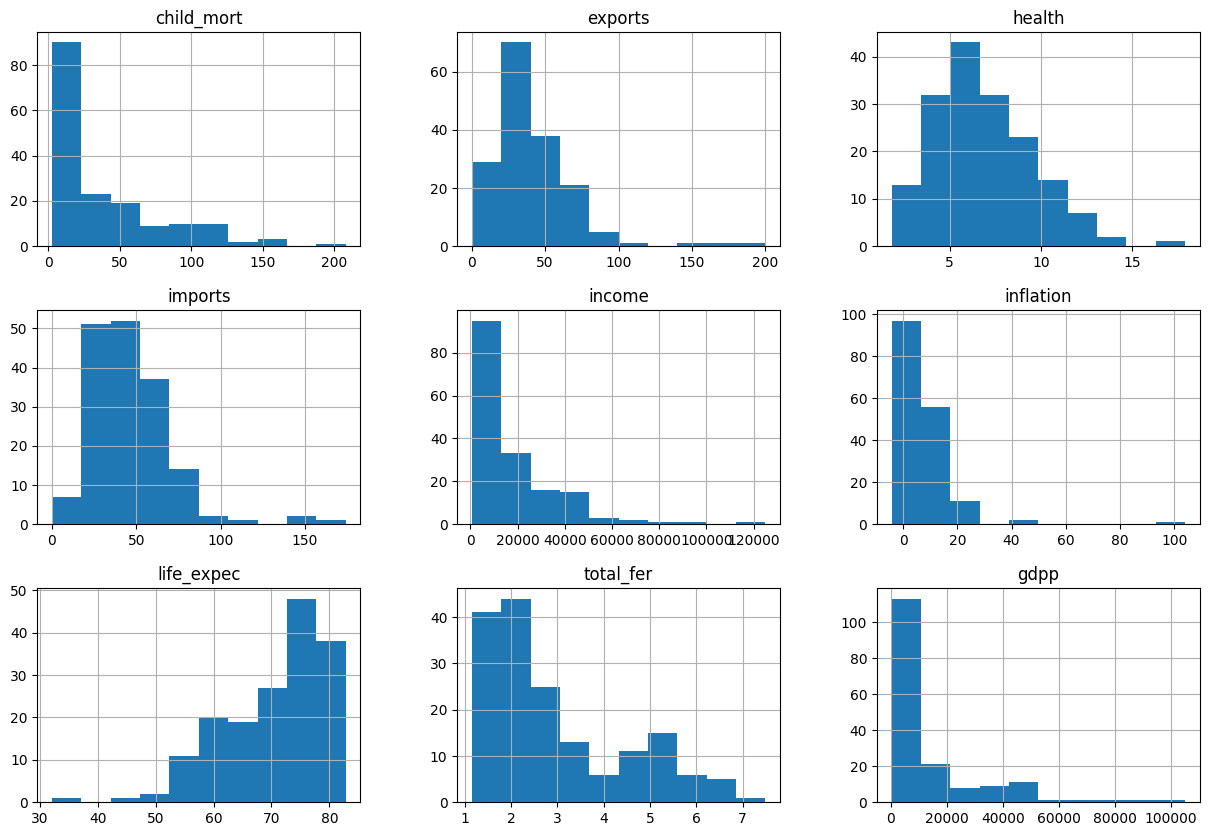

In [41]:
import matplotlib.pyplot as plt
df.hist(figsize=(15,10))
plt.show()

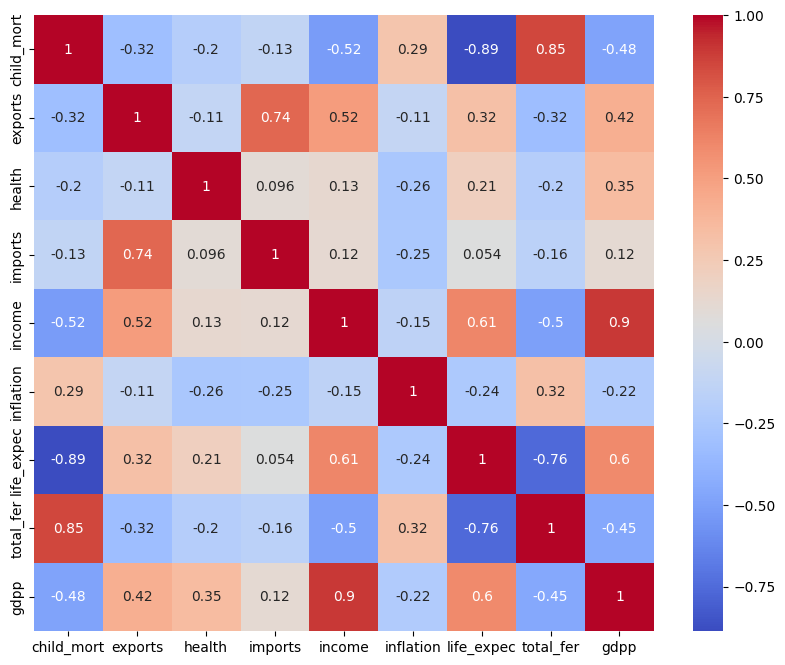

In [42]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [43]:
X = df.drop('country', axis = 1)

In [44]:
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(167, 2)


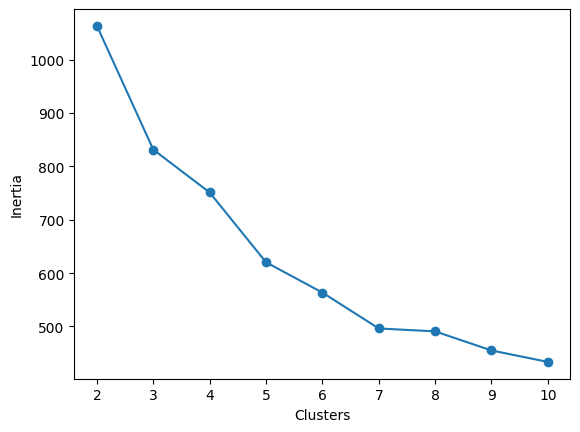

In [47]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia = []
for k in range(2,11):
  km = KMeans(n_clusters=k,random_state = 42)
  km.fit(X_scaled)
  inertia.append(km.inertia_)
plt.plot(range(2,11),inertia,marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [48]:
kmeans = KMeans(n_clusters=3,random_state  = 42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [49]:
from sklearn.metrics import silhouette_score
score = silhouette_score(
     X_scaled,
     clusters
 )
print(score)

0.285600988953231


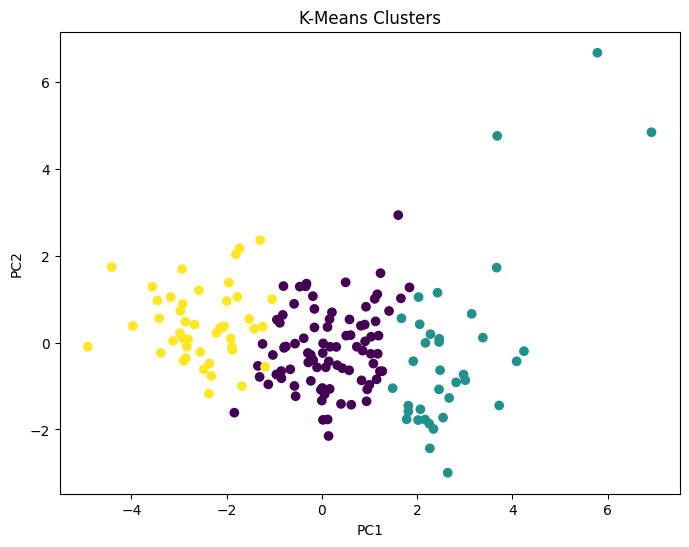

In [50]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters)
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [51]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5,min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_cluster'] = db_labels

In [52]:
df["DBSCAN_cluster"].value_counts()

,count
DBSCAN_cluster,
0,137
-1,30


In [53]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0         22.456977  40.273128  6.251047  47.362394  12321.744186   7.720884   
1          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
2         95.106667  28.602444  6.301111  42.306667   3539.844444  11.986778   

         life_expec  total_fer          gdpp  DBSCAN_cluster  
Cluster                                                       
0         72.566279   2.340349   6461.767442       -0.069767  
1         80.127778   1.752778  42494.444444       -0.250000  
2         59.055556   5.065333   1766.711111       -0.333333  


In [54]:
mapping = {
    0:"Developed",
    1:"Developing",
    2:"Underdeveloped"
}
df['Segment'] = df['Cluster'].map(mapping)

In [55]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Segment'])
X_cls = df.drop(
    [
        'country','Cluster','DBSCAN_cluster','Segment'
    ], axis=1
)

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score
lr_acc = accuracy_score(
    y_test,pred_lr
)
print(lr_acc)

0.9705882352941176


In [59]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [60]:
rf_acc = accuracy_score(
    y_test,pred_rf
)
print(rf_acc)

0.9705882352941176


In [61]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train,y_train)
pred_xgb = xgb.predict(X_test)

In [62]:
xgb_acc = accuracy_score(y_test,pred_xgb)
print(xgb_acc)

0.9705882352941176


In [63]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        lr_acc,
        rf_acc,
        xgb_acc
    ]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.970588
1,Random Forest,0.970588
2,XGBoost,0.970588


In [64]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [65]:
importance = pd.DataFrame({'Feature':X_cls.columns,
                           'Importance':rf.feature_importances_})
importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,child_mort,0.296473
8,gdpp,0.228868
6,life_expec,0.158137
4,income,0.158125
7,total_fer,0.101352
2,health,0.021541
1,exports,0.013551
5,inflation,0.011513
3,imports,0.010440


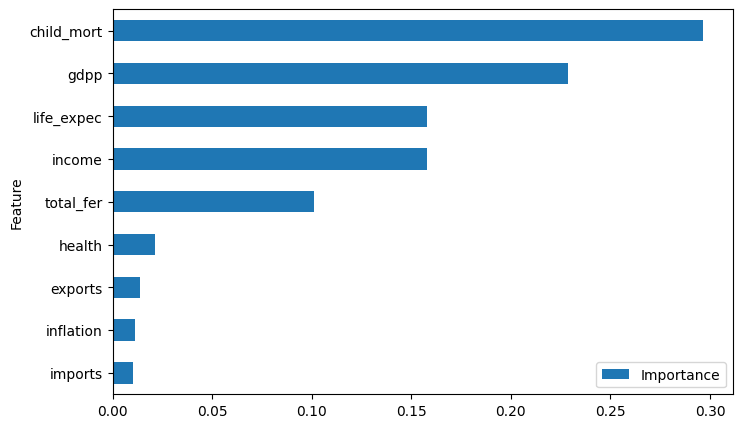

In [66]:
importance.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,5)
)
plt.show()